In [1]:
import pandas as pd
import os

# --- 1. CONFIGURACIÓN ---
ruta_de_la_carpeta = r'C:\Users\Juan_Saa\Desktop\BD_PSO23L13\Señales\Señales_CHEC'

# ✅ CORRECCIÓN AQUÍ: Solo el nombre del archivo con su extensión .csv
nombre_archivo_salida = r'C:\Users\Juan_Saa\Desktop\BD_PSO23L13\CHEC\Señales_CHEC.csv'
# -------------------------


# Lista para almacenar los datos de cada archivo
lista_de_datos = []

print(f"Buscando archivos de Excel en: {ruta_de_la_carpeta}...")

# (El resto del código sigue igual)
for archivo in os.listdir(ruta_de_la_carpeta):
    if archivo.endswith('.xlsx') or archivo.endswith('.xls'):
        ruta_completa = os.path.join(ruta_de_la_carpeta, archivo)
        try:
            df = pd.read_excel(ruta_completa)
            nombre_señal = os.path.splitext(archivo)[0]
            df['Señal'] = nombre_señal
            lista_de_datos.append(df)
            print(f"-> Procesado exitosamente: {archivo}")
        except Exception as e:
            print(f"!! Error al leer el archivo {archivo}: {e}")

if not lista_de_datos:
    print("\nNo se encontraron archivos de Excel en la carpeta especificada.")
else:
    df_unificado = pd.concat(lista_de_datos, ignore_index=True)
    
    # Esta línea ahora funcionará correctamente
    ruta_salida_csv = os.path.join(ruta_de_la_carpeta, nombre_archivo_salida)
    
    df_unificado.to_csv(ruta_salida_csv, index=False, encoding='utf-8-sig')
    
    print(f"\n¡Proceso completado! ✅")
    print(f"Se han unificado {len(lista_de_datos)} archivos.")
    print(f"El archivo final se ha guardado en: {ruta_salida_csv}")

Buscando archivos de Excel en: C:\Users\Juan_Saa\Desktop\BD_PSO23L13\Señales\Señales_CHEC...
-> Procesado exitosamente: Sag_01.xls
-> Procesado exitosamente: Sag_02.xls
-> Procesado exitosamente: Sag_03.xls
-> Procesado exitosamente: Sag_04.xls
-> Procesado exitosamente: Sag_05.xls
-> Procesado exitosamente: Sag_06.xls
-> Procesado exitosamente: Sag_07.xls
-> Procesado exitosamente: Sag_08.xls
-> Procesado exitosamente: Sag_09.xls
-> Procesado exitosamente: Sag_10.xls
-> Procesado exitosamente: Sag_11.xls
-> Procesado exitosamente: Sag_12.xls
-> Procesado exitosamente: Sag_13.xls
-> Procesado exitosamente: Sag_14.xls
-> Procesado exitosamente: Sag_15.xls
-> Procesado exitosamente: Sag_16.xls
-> Procesado exitosamente: Sag_17.xls
-> Procesado exitosamente: Sag_18.xls
-> Procesado exitosamente: Sag_19.xls
-> Procesado exitosamente: Sag_20.xls
-> Procesado exitosamente: Sag_21 (1).xls
-> Procesado exitosamente: Sag_21.xls
-> Procesado exitosamente: Sag_22.xls
-> Procesado exitosamente: Sa

In [29]:
import pandas as pd
import os

# --- 1. CONFIGURACIÓN ---
# Por favor, modifica esta línea con la ruta a la carpeta donde está tu CSV.
ruta_de_la_carpeta = r'C:\Users\Juan_Saa\Desktop\BD_PSO23L13\ENEA\Multi_Estado'

# Nombre del archivo CSV que vamos a leer.
nombre_archivo_entrada = r'C:\Users\Juan_Saa\Desktop\BD_PSO23L13\ENEA\Multi_Estado\Señales_ENEA_Multiestado.csv'

# Nombre para el nuevo archivo CSV que se creará con la columna ID.
nombre_archivo_salida = r'C:\Users\Juan_Saa\Desktop\BD_PSO23L13\ENEA\Multi_Estado\Señales_ENEA_Multiestado.csv'
# -------------------------

# Construir la ruta completa del archivo de entrada
ruta_entrada_csv = os.path.join(ruta_de_la_carpeta, nombre_archivo_entrada)

try:
    # Leer el archivo CSV
    df = pd.read_csv(ruta_entrada_csv)
    print(f"Archivo '{nombre_archivo_entrada}' cargado exitosamente.")

    # --- LÓGICA PRINCIPAL ---
    
    # 1. Obtener los nombres de señal únicos para asignar un ID a cada uno.
    señales_unicas = df['Señal'].unique()

    # 2. Crear un diccionario que asocia cada señal con un ID único.
    #    Ejemplo: {'señal_falla_A': 'Sag_1', 'señal_falla_B': 'Sag_2'}
    mapeo_id = {señal: f'Sag_{i+1}' for i, señal in enumerate(señales_unicas)}
    
    # 3. CREAR LA NUEVA COLUMNA 'ID_Falla'
    #    Se usa la columna 'Señal' para saber qué ID poner en cada fila.
    df['ID_Falla'] = df['Señal'].map(mapeo_id)
    
    print("Nueva columna 'ID_Falla' creada exitosamente.")

    # --- FIN DE LA LÓGICA ---

    # Construir la ruta final del archivo de salida
    ruta_salida_csv = os.path.join(ruta_de_la_carpeta, nombre_archivo_salida)

    # Guardar el DataFrame con la nueva columna en un archivo CSV diferente
    df.to_csv(ruta_salida_csv, index=False, encoding='utf-8-sig')
    
    print(f"\n¡Proceso finalizado! ✅")
    print(f"Se ha creado un nuevo archivo con el ID de cada falla.")
    print(f"Archivo generado: {nombre_archivo_salida}")
    print(f"Ubicación: {ruta_salida_csv}")

except FileNotFoundError:
    print(f"!! ERROR: No se pudo encontrar el archivo '{nombre_archivo_entrada}' en la ruta especificada.")
    print(f"Por favor, asegúrate de que la ruta '{ruta_de_la_carpeta}' es correcta y el archivo existe.")
except Exception as e:
    print(f"!! Ocurrió un error inesperado: {e}")

Archivo 'C:\Users\Juan_Saa\Desktop\BD_PSO23L13\ENEA\Multi_Estado\Señales_ENEA_Multiestado.csv' cargado exitosamente.
Nueva columna 'ID_Falla' creada exitosamente.

¡Proceso finalizado! ✅
Se ha creado un nuevo archivo con el ID de cada falla.
Archivo generado: C:\Users\Juan_Saa\Desktop\BD_PSO23L13\ENEA\Multi_Estado\Señales_ENEA_Multiestado.csv
Ubicación: C:\Users\Juan_Saa\Desktop\BD_PSO23L13\ENEA\Multi_Estado\Señales_ENEA_Multiestado.csv


In [4]:
import pandas as pd
import os

# --- 1. CONFIGURACIÓN ---
# Por favor, modifica esta línea con la ruta a la carpeta donde está tu CSV.
ruta_de_la_carpeta = r'C:\Users\Juan_Saa\Desktop\BD_PSO23L13\CHEC'
# Nombre del archivo CSV que vamos a analizar.
nombre_archivo_entrada = r'C:\Users\Juan_Saa\Desktop\BD_PSO23L13\CHEC\Señales_CHEC.csv'

# Nombre para el nuevo archivo CSV con el resumen de los segmentos.
nombre_archivo_salida = r'C:\Users\Juan_Saa\Desktop\BD_PSO23L13\CHEC\Resumen_CHEC.csv'
# -------------------------

# Construir la ruta completa del archivo de entrada
ruta_entrada_csv = os.path.join(ruta_de_la_carpeta, nombre_archivo_entrada)

try:
    # Leer el archivo CSV
    df = pd.read_csv(ruta_entrada_csv)
    print(f"✅ Archivo '{nombre_archivo_entrada}' cargado exitosamente.")
    print("Las columnas encontradas son:", df.columns.to_list())
    
    # --- ANÁLISIS 1: Contar las Clases de Hundimiento ---
    print("\n" + "="*50)
    print("📊 ANÁLISIS DE 'Clase de Hundimiento'")
    print("="*50)
    
    # Contar cuántas clases únicas hay
    clases_unicas = df['Señal'].unique()
    num_clases = len(clases_unicas)
    
    print(f"Número total de 'Clase de Hundimiento' únicas: {num_clases}")
    print("Los tipos encontrados son:", clases_unicas)

    # --- ANÁLISIS 2: Contar cuántas señales (IDs) hay por cada clase ---
    print("\n" + "="*50)
    print("📊 CONTEO DE SEÑALES POR CLASE")
    print("="*50)
    
    # Agrupar por 'Clase de Hundimiento' y contar los 'ID_Falla' únicos en cada grupo
    conteo_por_clase = df.groupby('Señal')['ID_Falla'].nunique()
    
    print("Número de fallas (IDs) por cada Clase de Hundimiento:")
    print(conteo_por_clase)
    print("-"*50)

    # --- ANÁLISIS 3: Extraer Segmento1 y Segmento2 por cada ID_Falla ---
    print("\n" + "="*50)
    print("🔎 EXTRACCIÓN DE SEGMENTOS POR ID DE FALLA")
    print("="*50)
    
    # Seleccionar las columnas relevantes y eliminar filas duplicadas para tener una entrada por ID
    resumen_segmentos = df[['ID_Falla', 'Señal', 'Fases(s) afectada(s)', 'Tiempo_1', 'Tiempo_2','Tiempo_3','Tiempo_4']].drop_duplicates(subset=['ID_Falla'])

    # Ordenar por el ID para un resultado más limpio
    resumen_segmentos = resumen_segmentos.sort_values(by='ID_Falla').reset_index(drop=True)
    
    print("A continuación se muestra un resumen de los segmentos para cada falla:")
    print(resumen_segmentos)
    
    # Guardar este resumen en un nuevo archivo CSV
    ruta_salida_csv = os.path.join(ruta_de_la_carpeta, nombre_archivo_salida)
    resumen_segmentos.to_csv(ruta_salida_csv, index=False, encoding='utf-8-sig')
    
    print(f"\n✅ ¡Análisis completado!")
    print(f"El resumen de los segmentos ha sido guardado en: {ruta_salida_csv}")


except FileNotFoundError:
    print(f"‼️ ERROR: No se pudo encontrar el archivo '{nombre_archivo_entrada}'.")
    print(f"Por favor, asegúrate de que la ruta '{ruta_de_la_carpeta}' es correcta.")
except KeyError as e:
    print(f"‼️ ERROR de columna: No se encontró la columna {e}.")
    print("Verifica que los nombres de las columnas en tu CSV coincidan con los del script.")
except Exception as e:
    print(f"‼️ Ocurrió un error inesperado: {e}")

✅ Archivo 'C:\Users\Juan_Saa\Desktop\BD_PSO23L13\CHEC\Señales_CHEC.csv' cargado exitosamente.
Las columnas encontradas son: ['Time', ' Va', ' Vb', ' Vc', 'Señal', ' Ia', ' Ib', ' Ic', 'Unnamed: 7', 'ID_Falla']

📊 ANÁLISIS DE 'Clase de Hundimiento'
Número total de 'Clase de Hundimiento' únicas: 31
Los tipos encontrados son: ['Sag_01' 'Sag_02' 'Sag_03' 'Sag_04' 'Sag_05' 'Sag_06' 'Sag_07' 'Sag_08'
 'Sag_09' 'Sag_10' 'Sag_11' 'Sag_12' 'Sag_13' 'Sag_14' 'Sag_15' 'Sag_16'
 'Sag_17' 'Sag_18' 'Sag_19' 'Sag_20' 'Sag_21 (1)' 'Sag_21' 'Sag_22'
 'Sag_23' 'Sag_24' 'Sag_25' 'Sag_26' 'Sag_27' 'Sag_28' 'Sag_29' 'Sag_30']

📊 CONTEO DE SEÑALES POR CLASE
Número de fallas (IDs) por cada Clase de Hundimiento:
Señal
Sag_01        1
Sag_02        1
Sag_03        1
Sag_04        1
Sag_05        1
Sag_06        1
Sag_07        1
Sag_08        1
Sag_09        1
Sag_10        1
Sag_11        1
Sag_12        1
Sag_13        1
Sag_14        1
Sag_15        1
Sag_16        1
Sag_17        1
Sag_18        1
Sag_19  

In [32]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import os

# --- 1. CONFIGURACIÓN ---
# Por favor, modifica esta línea con la ruta a la carpeta donde está tu CSV.
ruta_de_la_carpeta = r'C:\Users\Juan_Saa\Desktop\BD_PSO23L13\EPRI'
nombre_archivo_entrada = r'C:\Users\Juan_Saa\Desktop\BD_PSO23L13\EPRI\Señales_EPRI.csv'
nombre_archivo_salida =r'C:\Users\Juan_Saa\Desktop\BD_PSO23L13\EPRI\Señales_EPRI_Normalizadas.csv'
# -------------------------

# Construir la ruta completa del archivo de entrada
ruta_entrada_csv = os.path.join(ruta_de_la_carpeta, nombre_archivo_entrada)

try:
    # Leer el archivo CSV
    df = pd.read_csv(ruta_entrada_csv)
    print(f"✅ Archivo '{nombre_archivo_entrada}' cargado exitosamente.")
    
    # --- LÓGICA DE NORMALIZACIÓN ---

    # 1. Definir las columnas que quieres intentar normalizar.
    #    (El script solo normalizará las que sean numéricas y existan en el archivo)
    columnas_a_normalizar = ['Va', 'Vb', 'Vc',]
    
    # 2. Filtrar la lista para quedarnos solo con las columnas que realmente existen en el DataFrame.
    columnas_existentes = [col for col in columnas_a_normalizar if col in df.columns]
    
    # 3. Asegurarse de que estas columnas sean numéricas antes de procesarlas.
    columnas_numericas = df[columnas_existentes].select_dtypes(include=['number']).columns.tolist()
    
    if not columnas_numericas:
        print("‼️ No se encontraron columnas numéricas para normalizar de la lista proporcionada.")
    else:
        print(f"\nSe normalizarán las siguientes columnas: {columnas_numericas}")
        
        # 4. Inicializar el escalador Min-Max.
        scaler = MinMaxScaler(feature_range=(-1.05, 1.05))
        
        # 5. Aplicar la normalización a las columnas seleccionadas.
        #    Se crea una copia para evitar advertencias de pandas.
        df_normalizado = df.copy()
        df_normalizado[columnas_numericas] = scaler.fit_transform(df[columnas_numericas])
        
        # --- FIN DE LA LÓGICA ---

        # Construir la ruta final del archivo de salida
        ruta_salida_csv = os.path.join(ruta_de_la_carpeta, nombre_archivo_salida)

        # Guardar el DataFrame con los datos normalizados en un nuevo archivo
        df_normalizado.to_csv(ruta_salida_csv, index=False, encoding='utf-8-sig')
        
        print(f"\n✅ ¡Proceso finalizado!")
        print(f"Los datos normalizados han sido guardados en: {nombre_archivo_salida}")
        print(f"Ubicación: {ruta_salida_csv}")

except FileNotFoundError:
    print(f"‼️ ERROR: No se pudo encontrar el archivo '{nombre_archivo_entrada}'.")
    print(f"Por favor, asegúrate de que la ruta '{ruta_de_la_carpeta}' es correcta.")
except Exception as e:
    print(f"‼️ Ocurrió un error inesperado: {e}")

✅ Archivo 'C:\Users\Juan_Saa\Desktop\BD_PSO23L13\EPRI\Señales_EPRI.csv' cargado exitosamente.

Se normalizarán las siguientes columnas: ['Va', 'Vb', 'Vc']

✅ ¡Proceso finalizado!
Los datos normalizados han sido guardados en: C:\Users\Juan_Saa\Desktop\BD_PSO23L13\EPRI\Señales_EPRI_Normalizadas.csv
Ubicación: C:\Users\Juan_Saa\Desktop\BD_PSO23L13\EPRI\Señales_EPRI_Normalizadas.csv


In [ ]:
import pandas as pd
import os

# --- 1. CONFIGURACIÓN ---
# Por favor, modifica estas líneas con tus rutas y nombres de archivo.
ruta_de_la_carpeta = r'C:\Users\Juan_Saa\Desktop\BD_PSO23L13\EPRI'
nombre_archivo_entrada = r'C:\Users\Juan_Saa\Desktop\BD_PSO23L13\EPRI\Señales_EPRI.csv'
nombre_archivo_salida =r'C:\Users\Juan_Saa\Desktop\BD_PSO23L13\EPRI\Señales_EPRI_Normalizadas.csv'
# -------------------------

# Construir la ruta completa del archivo de entrada
ruta_entrada_csv = os.path.join(ruta_de_la_carpeta, nombre_archivo_entrada)

try:
    # Cargar el archivo CSV
    df = pd.read_csv(ruta_entrada_csv)
    print("✅ Archivo cargado exitosamente.")
    
    # Es útil ver cómo Pandas nombra las columnas duplicadas (ej. 'Time', 'Time.1')
    print("Columnas originales encontradas:", df.columns.to_list())

    # --- LÓGICA DE CONSOLIDACIÓN ---

    # 1. Identificar todas las posibles columnas de tiempo.
    #    (Pandas puede haberlas renombrado a 'Time.1', 'Time.2', etc.)
    columnas_tiempo_originales = [col for col in df.columns if 'Time' in col or 'Tiempo' in col]
    if not columnas_tiempo_originales:
        raise ValueError("No se encontraron columnas de tiempo para consolidar.")
    print(f"\nSe consolidarán los datos de las siguientes columnas: {columnas_tiempo_originales}")
    
    # 2. Crear una nueva columna 'Time_Consolidado'
    #    Empezamos con la primera columna de tiempo encontrada.
    df['Time_Consolidado'] = df[columnas_tiempo_originales[0]]

    # 3. Usar un bucle y .fillna() para rellenar los vacíos con los valores de las otras columnas de tiempo.
    for col in columnas_tiempo_originales[1:]:
        df['Time_Consolidado'] = df['Time_Consolidado'].fillna(df[col])

    # 4. Eliminar las columnas de tiempo originales que ya no necesitamos.
    df = df.drop(columns=columnas_tiempo_originales)
    
    # 5. Renombrar la nueva columna a 'Time' y moverla al principio.
    df = df.rename(columns={'Time_Consolidado': 'Time'})
    columnas_finales = ['Time'] + [col for col in df.columns if col != 'Time']
    df_limpio = df[columnas_finales]

    print("\n-> Las columnas de tiempo han sido unificadas exitosamente.")
    print("Columnas finales:", df_limpio.columns.to_list())

    # --- GUARDAR EL RESULTADO ---
    ruta_salida_csv = os.path.join(ruta_de_la_carpeta, nombre_archivo_salida)
    df_limpio.to_csv(ruta_salida_csv, index=False, encoding='utf-8-sig')

    print(f"\n✅ ¡Proceso finalizado!")
    print(f"El archivo ajustado ha sido guardado como: {nombre_archivo_salida}")

except FileNotFoundError:
    print(f"‼️ ERROR: No se pudo encontrar el archivo '{nombre_archivo_entrada}'. Revisa la ruta.")
except ValueError as ve:
    print(f"‼️ ERROR: {ve}")
except Exception as e:
    print(f"‼️ Ocurrió un error inesperado: {e}")

✅ Archivo cargado exitosamente.
Columnas originales encontradas: ['Time (s)', ' Va', ' Vb', ' Vc', 'Señal', 'Time', 'Time ', ' Ia', ' Ib', ' Ic', 'Unnamed: 7', 'Tiempo inicial', 'ID_Falla']

Se consolidarán los datos de las siguientes columnas: ['Time (s)', 'Time', 'Time ', 'Tiempo inicial']

-> Las columnas de tiempo han sido unificadas exitosamente.
Columnas finales: ['Time', ' Va', ' Vb', ' Vc', 'Señal', ' Ia', ' Ib', ' Ic', 'Unnamed: 7', 'ID_Falla']

✅ ¡Proceso finalizado!
El archivo ajustado ha sido guardado como: C:\Users\Juan_Saa\Desktop\BD_PSO23L13\CHEC\Señales_CHEC.csv


In [7]:
import pandas as pd

# 1. Especifica la ruta y nombre de tu archivo CSV
nombre_archivo_entrada = r'Señales_Santiago\Resumen\Resumen_unificadas.csv'
nombre_archivo_salida = r'Señales_Santiago\Resumen\Resumen_unificadas.csv'

def ordenar_csv_por_id_falla(archivo_entrada, archivo_salida):
    """
    Carga un CSV con ID_Falla (Sag_[numero]), extrae el número y ordena los datos.
    """
    try:
        # Cargar el archivo CSV
        df = pd.read_csv(archivo_entrada)

        # 2. Crear una columna temporal con el valor numérico del ID_Falla
        # Usamos .str.replace() para quitar "Sag_" y luego convertimos a entero.
        df['ID_Num'] = df['ID_Falla'].str.replace('Sag_', '', regex=False).astype(int)

        # 3. Ordenar el DataFrame usando la nueva columna numérica
        # Esto asegura que el orden sea Sag_1, Sag_2, ..., Sag_10, ..., Sag_100
        df_ordenado = df.sort_values(by='ID_Num', ascending=True)

        # 4. Eliminar la columna temporal de numeración antes de guardar
        df_final = df_ordenado.drop(columns=['ID_Num'])

        # 5. Guardar el resultado en un nuevo archivo CSV
        # index=False evita que se guarde el índice de Pandas como una columna extra.
        df_final.to_csv(archivo_salida, index=False)

        print(f"✅ Archivo organizado exitosamente.")
        print(f"Se ha creado el archivo: {archivo_salida}")
        print("\n---")
        print("Primeras 5 filas del archivo ordenado:")
        print(df_final.head())

    except FileNotFoundError:
        print(f"❌ Error: El archivo de entrada '{archivo_entrada}' no se encontró.")
    except Exception as e:
        print(f"❌ Ocurrió un error inesperado: {e}")

# Ejecutar la función
ordenar_csv_por_id_falla(nombre_archivo_entrada, nombre_archivo_salida)

✅ Archivo organizado exitosamente.
Se ha creado el archivo: Señales_Santiago\Resumen\Resumen_unificadas.csv

---
Primeras 5 filas del archivo ordenado:
    ID_Falla                         Señal  Segmento1  Segmento2
0      Sag_1  FaseABC_RV0.3_Deg000_Salto10      512.0     1536.0
111    Sag_2  FaseABC_RV0.3_Deg000_Salto40      512.0     1536.0
222    Sag_3  FaseABC_RV0.3_Deg000_Salto70      512.0     1536.0
333    Sag_4  FaseABC_RV0.3_Deg030_Salto10      555.0     1536.0
386    Sag_5  FaseABC_RV0.3_Deg030_Salto40      555.0     1536.0


## Analisis


Cargando datos desde: C:\Users\Juan_Saa\Desktop\BD_PSO23L13\Metadatos.xlsx
Procesando 12 hojas...
 -> Procesando hoja: 'Va'
 -> Procesando hoja: 'Vab'
 -> Procesando hoja: 'Vabc'
 -> Procesando hoja: 'Vb'
 -> Procesando hoja: 'Vbc'
 -> Procesando hoja: 'Vca'
 -> Procesando hoja: 'Vc'
 -> Procesando hoja: 'IEEE'
 -> Procesando hoja: 'EPRI'
 -> Procesando hoja: 'ENEA_MONO'
 -> Procesando hoja: 'ENEA_MULTI'
 -> Procesando hoja: 'CHEC'

¡Extracción y mapeo de datos completados!

--- ANÁLISIS DE RENDIMIENTO POR TIPO DE FALLA ---

Reporte de Clasificación (Precisión, Recall, F1-Score):
              precision    recall  f1-score   support

  Monofásico       0.82      0.61      0.70        61
    Bifásico       0.89      0.46      0.61        37
   Trifásico       0.45      0.78      0.57        46

    accuracy                           0.62       144
   macro avg       0.72      0.62      0.63       144
weighted avg       0.72      0.62      0.63       144

Calculando la matriz de confusió

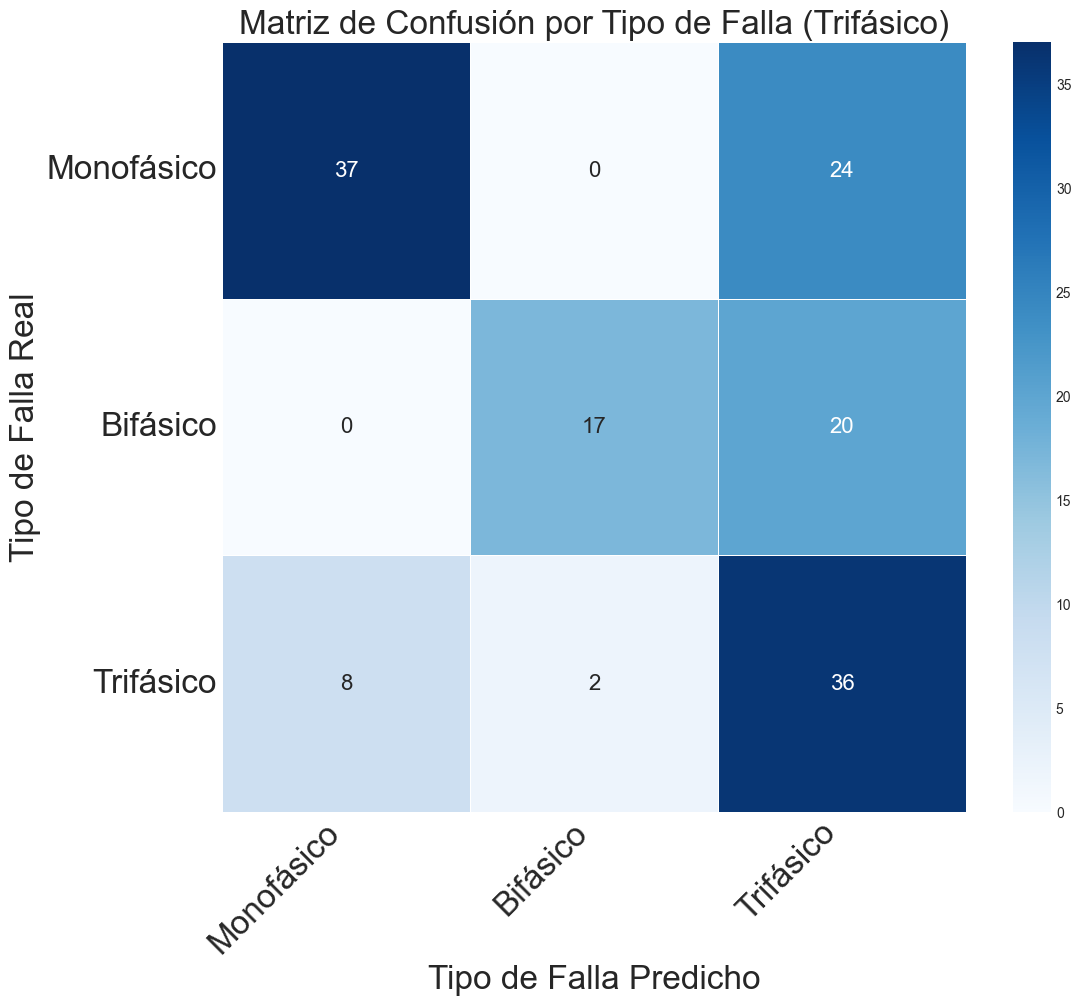

In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# ==============================================================================
# 1. PARÁMETROS - ¡AJUSTA ESTAS TRES VARIABLES!
# ==============================================================================

# Ruta completa a tu archivo de Excel
ruta_excel = r'C:\Users\Juan_Saa\Desktop\BD_PSO23L13\Metadatos.xlsx'

# Nombre de la columna que tiene el TIPO REAL (Mono, Bi, Tri)
columna_real_tipo = 'Clase_Tri'

# Nombre de la columna que tiene la PREDICCIÓN específica del modelo trifásico
columna_predicha_especifica = 'Clase_Clasificador_Trifasico'

# ==============================================================================
# 2. LÓGICA DE MAPEO (Según tus reglas)
# ==============================================================================

# Diccionario para "traducir" las predicciones específicas a su tipo general
mapeo_prediccion_a_tipo = {
    'Sag_C': 'Bi',
    'Sag_E': 'Bi',
    'Sag_B': 'Mono',
    'Sag_D': 'Mono',
    'Sag_A': 'Tri',
    'Sag_F': 'Tri',
    'Sag_G': 'Tri',
    'Normal': 'Normal'
}

def traducir_prediccion(prediccion):
    """Función que aplica el mapeo. Si no encuentra una clase, devuelve 'Desconocido'."""
    return mapeo_prediccion_a_tipo.get(prediccion, 'Desconocido')

# ==============================================================================
# 3. LEER DATOS, APLICAR MAPEO Y EXTRAER ETIQUETAS
# ==============================================================================
print(f"Cargando datos desde: {ruta_excel}")

try:
    diccionario_de_hojas = pd.read_excel(ruta_excel, sheet_name=None, engine='openpyxl')
    
    y_true_total = []
    y_pred_total = []

    print(f"Procesando {len(diccionario_de_hojas)} hojas...")

    for nombre_hoja, df_hoja in diccionario_de_hojas.items():
        print(f" -> Procesando hoja: '{nombre_hoja}'")
        
        df_hoja.dropna(subset=[columna_real_tipo, columna_predicha_especifica], inplace=True)
        
        etiquetas_reales = df_hoja[columna_real_tipo].tolist()
        etiquetas_predichas_traducidas = df_hoja[columna_predicha_especifica].apply(traducir_prediccion).tolist()
        
        y_true_total.extend(etiquetas_reales)
        y_pred_total.extend(etiquetas_predichas_traducidas)

    print("\n¡Extracción y mapeo de datos completados!")

except FileNotFoundError:
    print(f"Error: No se encontró el archivo en la ruta '{ruta_excel}'.")
    exit()
except KeyError as e:
    print(f"Error de columna: No se encontró la columna {e}. Revisa los nombres en las variables.")
    exit()

# ==============================================================================
# 4. CALCULAR MÉTRICAS Y GRAFICAR
# ==============================================================================

if y_true_total and y_pred_total:
    print("\n--- ANÁLISIS DE RENDIMIENTO POR TIPO DE FALLA ---")
    
    clases_ordenadas = ['Normal', 'Mono', 'Bi', 'Tri']
    clases_existentes = sorted(list(set(y_true_total + y_pred_total)))
    clases_finales = [c for c in clases_ordenadas if c in clases_existentes]
    
    mapeo_etiquetas_grafico = {
        'Mono': 'Monofásico',
        'Bi': 'Bifásico',
        'Tri': 'Trifásico',
        'Normal': 'Normal'
    }
    # Nombres completos de las clases para el reporte
    nombres_clases_reporte = [mapeo_etiquetas_grafico.get(c, c) for c in clases_finales]

    # --- ¡NUEVO! CÁLCULO E IMPRESIÓN DEL REPORTE DE CLASIFICACIÓN ---
    print("\nReporte de Clasificación (Precisión, Recall, F1-Score):")
    # Se genera el reporte con las etiquetas originales ('Mono', 'Bi', etc.)
    # y se le pasan los nombres completos para la visualización.
    reporte = classification_report(
        y_true_total,
        y_pred_total,
        labels=clases_finales,
        target_names=nombres_clases_reporte
    )
    print(reporte)
    
    # --- CÁLCULO Y GRÁFICO DE LA MATRIZ DE CONFUSIÓN (Sin cambios) ---
    print("Calculando la matriz de confusión...")
    matriz = confusion_matrix(y_true_total, y_pred_total, labels=clases_finales)
    df_matriz = pd.DataFrame(matriz, index=clases_finales, columns=clases_finales)
    
    df_matriz.rename(index=mapeo_etiquetas_grafico, columns=mapeo_etiquetas_grafico, inplace=True)
    
    plt.style.use('seaborn-v0_8-whitegrid')
    plt.figure(figsize=(12, 10))
    
    # --- CAMBIO 1: Números internos más grandes ---
    sns.heatmap(df_matriz, annot=True, fmt='d', cmap='Blues', linewidths=.5,
                annot_kws={"size": 16}) # <-- Tamaño de números
    
    plt.title('Matriz de Confusión por Tipo de Falla (Trifásico)', fontsize=24)
    plt.ylabel('Tipo de Falla Real', fontsize=24)
    plt.xlabel('Tipo de Falla Predicho', fontsize=24)
    
    # --- CAMBIO 2: Etiquetas de ejes más grandes ---
    plt.xticks(rotation=45, ha='right', fontsize=24) # <-- Tamaño de clases eje X
    plt.yticks(rotation=0, fontsize=24)              # <-- Tamaño de clases eje Y
    
    ruta_guardado = 'matriz_confusion_por_tipo.png'
    plt.savefig(ruta_guardado, bbox_inches='tight')
    
    print(f"\n¡Gráfico guardado como '{ruta_guardado}'!")
    plt.savefig("Trifasico.svg")
    plt.show()

else:
    print("No se encontraron datos válidos para procesar.")

Cargando datos desde: C:\Users\Juan_Saa\Desktop\BD_PSO23L13\Metadatos.xlsx
Procesando 12 hojas...
 -> Procesando hoja: 'Va'
 -> Procesando hoja: 'Vab'
 -> Procesando hoja: 'Vabc'
 -> Procesando hoja: 'Vb'
 -> Procesando hoja: 'Vbc'
 -> Procesando hoja: 'Vca'
 -> Procesando hoja: 'Vc'
 -> Procesando hoja: 'IEEE'
 -> Procesando hoja: 'EPRI'
 -> Procesando hoja: 'ENEA_MONO'
 -> Procesando hoja: 'ENEA_MULTI'
 -> Procesando hoja: 'CHEC'

¡Extracción de datos de todas las fases completada!

--- ANÁLISIS DE RENDIMIENTO DEL MODELO MONOFÁSICO ---

Reporte de Clasificación (Monofásico):
              precision    recall  f1-score   support

      Normal       0.87      0.91      0.89       153
         Sag       0.87      0.73      0.79       215
Sag_Armonico       0.72      0.95      0.82        19
Sag_Multiple       0.37      0.56      0.45        45

    accuracy                           0.78       432
   macro avg       0.71      0.79      0.74       432
weighted avg       0.81      0.78   

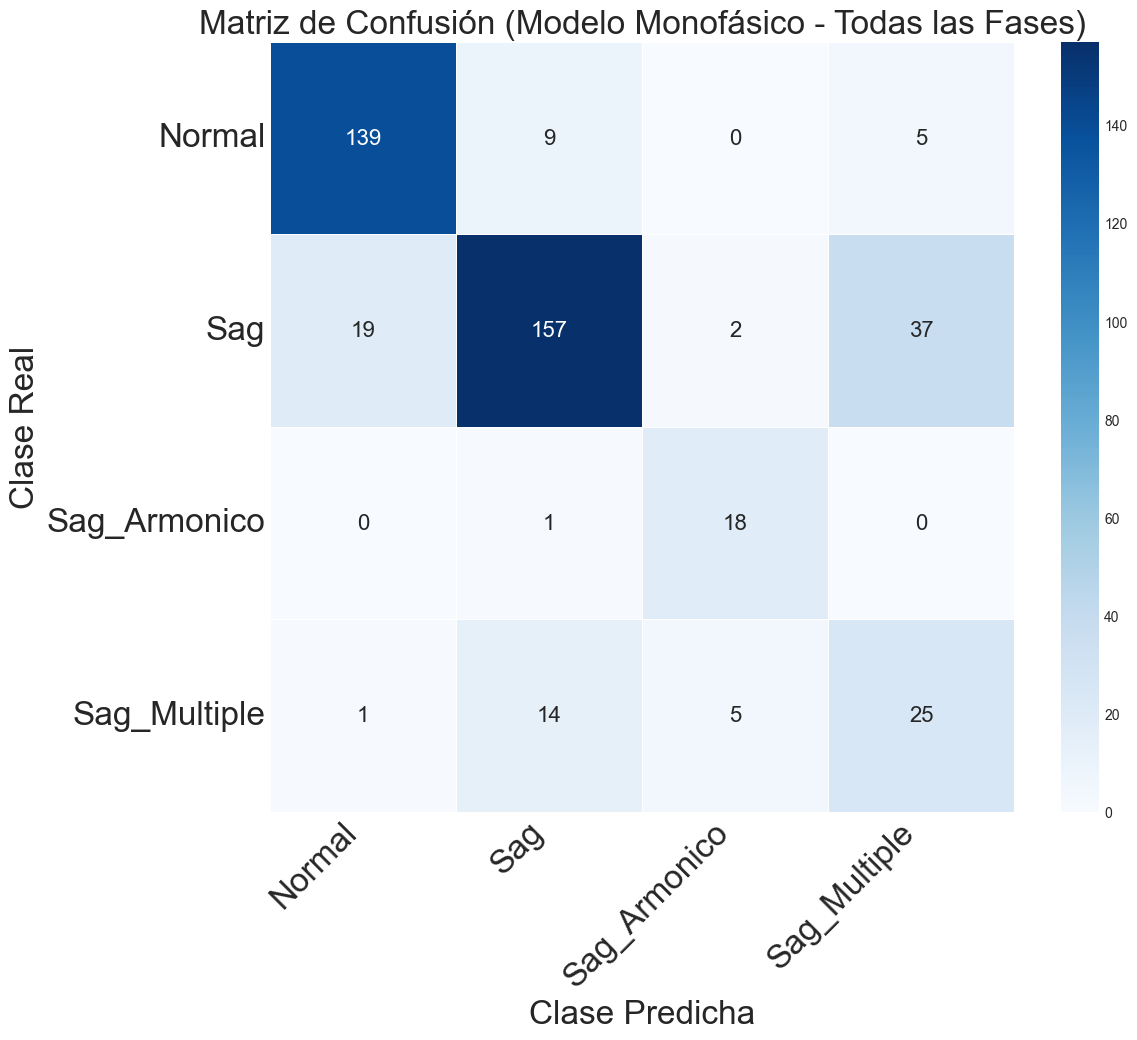

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# ==============================================================================
# 1. PARÁMETROS - ¡AJUSTA ESTAS VARIABLES SI ES NECESARIO!
# ==============================================================================

# Ruta completa a tu archivo de Excel
ruta_excel = r'C:\Users\Juan_Saa\Desktop\BD_PSO23L13\Metadatos.xlsx' 

# Nombres de las columnas que contienen las etiquetas REALES por fase
columnas_reales = ['Clase_Mono_A', 'Clase_Mono_B', 'Clase_Mono_C']

# Nombres de las columnas que contienen las PREDICCIONES del modelo por fase
columnas_predichas = ['Clase_Clasificador_Mono_A', 'Clase_Clasificador_Mono_B', 'Clase_Clasificador_Mono_C']

# ==============================================================================
# 2. LEER DATOS, RECORRER FASES Y EXTRAER ETIQUETAS
# ==============================================================================
print(f"Cargando datos desde: {ruta_excel}")

try:
    diccionario_de_hojas = pd.read_excel(ruta_excel, sheet_name=None, engine='openpyxl')
    
    y_true_total = []
    y_pred_total = []

    print(f"Procesando {len(diccionario_de_hojas)} hojas...")

    # Iterar sobre cada hoja en el archivo
    for nombre_hoja, df_hoja in diccionario_de_hojas.items():
        print(f" -> Procesando hoja: '{nombre_hoja}'")
        
        # Iterar sobre cada par de columnas (real y predicha) para las fases A, B y C
        for col_real, col_pred in zip(columnas_reales, columnas_predichas):
            
            # Asegurarse de que ambas columnas existen en la hoja actual
            if col_real in df_hoja.columns and col_pred in df_hoja.columns:
                
                # Crear un DataFrame temporal con solo las dos columnas de interés
                df_fase = df_hoja[[col_real, col_pred]].copy()
                
                # Eliminar filas donde falte alguna de las dos etiquetas
                df_fase.dropna(inplace=True)
                
                # Añadir las etiquetas de esta fase a las listas totales
                y_true_total.extend(df_fase[col_real].tolist())
                y_pred_total.extend(df_fase[col_pred].tolist())

    print("\n¡Extracción de datos de todas las fases completada!")

except FileNotFoundError:
    print(f"Error: No se encontró el archivo en la ruta '{ruta_excel}'.")
    exit()
except KeyError as e:
    print(f"Error de columna: No se encontró la columna {e}. Revisa los nombres en las variables.")
    exit()

# ==============================================================================
# 3. CALCULAR MÉTRICAS Y GRAFICAR
# ==============================================================================

if y_true_total and y_pred_total:
    print("\n--- ANÁLISIS DE RENDIMIENTO DEL MODELO MONOFÁSICO ---")
    
    # Obtener todas las clases únicas en orden alfabético para el reporte y la matriz
    clases = sorted(list(set(y_true_total + y_pred_total)))
    
    # --- 3.1. Reporte de Clasificación (Precisión, Recall, F1-Score) ---
    print("\nReporte de Clasificación (Monofásico):")
    reporte = classification_report(y_true_total, y_pred_total, labels=clases)
    print(reporte)
    
    # --- 3.2. Matriz de Confusión ---
    print("Calculando la matriz de confusión...")
    matriz = confusion_matrix(y_true_total, y_pred_total, labels=clases)
    df_matriz = pd.DataFrame(matriz, index=clases, columns=clases)
    
    # Graficar la matriz de confusión
    plt.style.use('seaborn-v0_8-whitegrid')
    plt.figure(figsize=(12, 10))
    
    # Añadido annot_kws para controlar el tamaño de la fuente de los números
    sns.heatmap(df_matriz, annot=True, fmt='d', cmap='Blues', linewidths=.5, 
                annot_kws={"size": 16}) # <-- Tamaño de números
    
    plt.title('Matriz de Confusión (Modelo Monofásico - Todas las Fases)', fontsize=24)
    plt.ylabel('Clase Real', fontsize=24)
    plt.xlabel('Clase Predicha', fontsize=24)
    
    # Añadido fontsize para controlar el tamaño de las etiquetas de los ejes
    plt.xticks(rotation=45, ha='right', fontsize=24) # <-- Tamaño de clases eje X
    plt.yticks(rotation=0, fontsize=24)             # <-- Tamaño de clases eje Y
    
    ruta_guardado = 'matriz_confusion_monofasico.png'
    plt.savefig(ruta_guardado, bbox_inches='tight')
    
    print(f"\n¡Gráfico guardado como '{ruta_guardado}'!")
    plt.savefig("Monofasico.svg")
    plt.show()

else:
    print("No se encontraron datos válidos para procesar.")